# Librery Book Borrowing Analyzer using Python

## Project Description

### Today I am creating a Python project called Librery Book Borrowing Analyzer using Python in Jupyter Notebook with Codex
###  The goal of this project is to create librery borrowing data, analyze book category, compare borrowed quantities, identify the most popular categories, and visualize the results using Pandas and Matplotlib.

In [23]:
# import libraries

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')


## Create Librery Borrowing Dataset

In [24]:
# Now I will create a librery borrowing dataset with book categories, borrowers, borrowed quantities, and borrowing dates.

np.random.seed(42)

book_categories = ['Fiction', 'Science', 'History', 'Technology', 'Children', 'Biography', 'Comics']
borrowers = ['Student', 'Teacher', 'Researcher', 'Visitor']
book_titles = [
    'Hidden River', 'Physics Made Simple', 'World Civilizations', 'Python Essentials',
    'Magic Forest', 'Life of a Leader', 'Hero Squad', 'Data Thinking',
    'Stars and Space', 'Ancient Kingdoms', 'Creative Coding', 'Young Explorers'
]

borrowing_data = pd.DataFrame({
    'Borrow Date': pd.date_range(start='2025-01-01', periods=300, freq='D'),
    'Book Title': np.random.choice(book_titles, size=300),
    'Category': np.random.choice(book_categories, size=300, p=[0.22, 0.14, 0.12, 0.18, 0.14, 0.10, 0.10]),
    'Borrower Type': np.random.choice(borrowers, size=300, p=[0.45, 0.20, 0.20, 0.15]),
    'Borrowed Quantity': np.random.randint(1, 8, size=300),
    'Return Days': np.random.randint(3, 21, size=300)
})

borrowing_data.head()


,Borrow Date,Book Title,Category,Borrower Type,Borrowed Quantity,Return Days
0,2025-01-01,Hero Squad,Children,Student,3,10
1,2025-01-02,Python Essentials,Biography,Student,4,13
2,2025-01-03,Creative Coding,Biography,Student,4,6
3,2025-01-04,Data Thinking,History,Student,4,19
4,2025-01-05,Magic Forest,Biography,Teacher,4,9


## Display Basic Information

In [25]:
# Display dataset shape, column names, and data types
print('Dataset shape:', borrowing_data.shape)
print('\nColumn names:')
print(borrowing_data.columns.tolist())
print('\nData types:')
print(borrowing_data.dtypes)


Dataset shape: (300, 6)

Column names:
['Borrow Date', 'Book Title', 'Category', 'Borrower Type', 'Borrowed Quantity', 'Return Days']

Data types:
Borrow Date          datetime64[ns]
Book Title                   object
Category                     object
Borrower Type                object
Borrowed Quantity             int64
Return Days                   int64
dtype: object


## Summary Statistics

In [15]:
# Show summary statistics for the numerical columns
borrowing_data.describe()


,Borrow Date,Borrowed Quantity,Return Days
count,300,300.000000,300.000000
mean,2025-05-30 12:00:00,3.970000,11.776667
min,2025-01-01 00:00:00,1.000000,3.000000
25%,2025-03-16 18:00:00,2.000000,7.000000
50%,2025-05-30 12:00:00,4.000000,12.000000
75%,2025-08-13 06:00:00,6.000000,16.000000
max,2025-10-27 00:00:00,7.000000,20.000000
std,NaN,2.038698,5.186178


## Analyze Book Category Borrowing


In [16]:

# Count how many borrowing records belong to each category
category_counts = borrowing_data['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Borrow Record Count']
category_counts


,Category,Borrow Record Count
0,Fiction,57
1,Technology,54
2,Science,49
3,Children,38
4,History,36
5,Comics,36
6,Biography,30


## Compare Borrowed Quantities by Category

In [26]:
# Calculate total borrowed quantity for each category
quantity_by_category = borrowing_data.groupby('Category')['Borrowed Quantity'].sum().sort_values(ascending=False)
quantity_by_category


Category
Fiction       226
Science       214
Technology    194
Children      160
Biography     141
History       135
Comics        121
Name: Borrowed Quantity, dtype: int64

## Identify the Most Popular Category

In [28]:
# Find the category with the highest total borrowed quantity
most_popular_category = quantity_by_category.idxmax()
highest_quantity = quantity_by_category.max()

print('Most popular category:', most_popular_category)
print('Highest borrowed quantity:', highest_quantity)


Most popular category: Fiction
Highest borrowed quantity: 226


## Analyze Borrowing by Borrower Type


In [29]:
# Compare total borrowed quantity across borrower types
borrower_summary = borrowing_data.groupby('Borrower Type')['Borrowed Quantity'].sum().sort_values(ascending=False)
borrower_summary


Borrower Type
Student       453
Teacher       323
Researcher    253
Visitor       162
Name: Borrowed Quantity, dtype: int64

## Monthly Borrowing Trend


In [31]:
# Create a monthly trend of borrowed quantities
monthly_borrowing = borrowing_data.set_index('Borrow Date')['Borrowed Quantity'].resample('M').sum()
monthly_borrowing



/var/folders/ch/3fpk8nds1y53s4p0_c1zlv540000gn/T/ipykernel_5840/3558321406.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_borrowing = borrowing_data.set_index('Borrow Date')['Borrowed Quantity'].resample('M').sum()


Borrow Date
2025-01-31    132
2025-02-28    103
2025-03-31    105
2025-04-30    128
2025-05-31    126
2025-06-30    141
2025-07-31    127
2025-08-31    112
2025-09-30    116
2025-10-31    101
Freq: ME, Name: Borrowed Quantity, dtype: int64

## Visualize Borrow Record Count by Category


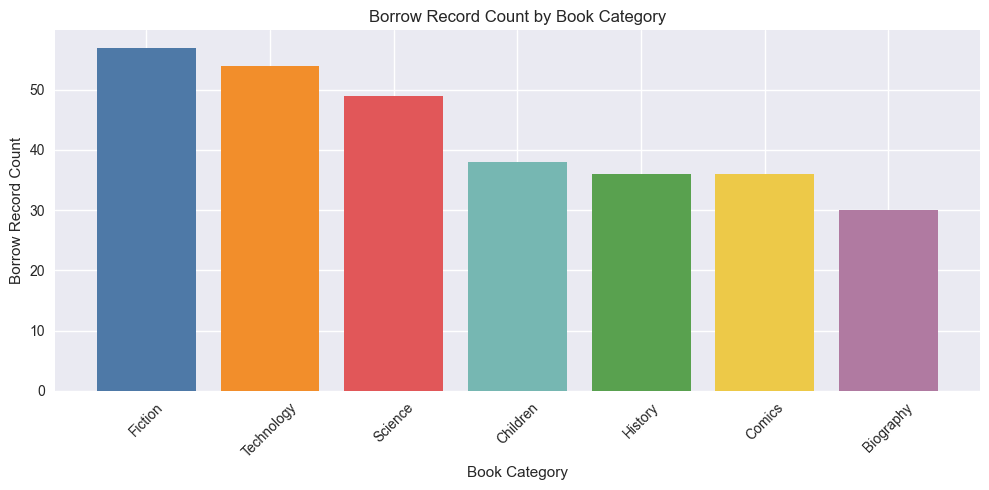

In [33]:
# Multicolor bar chart for borrow record count by category
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948', '#b07aa1']

plt.figure(figsize=(10, 5))
plt.bar(category_counts['Category'], category_counts['Borrow Record Count'], color=colors)
plt.title('Borrow Record Count by Book Category')
plt.xlabel('Book Category')
plt.ylabel('Borrow Record Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


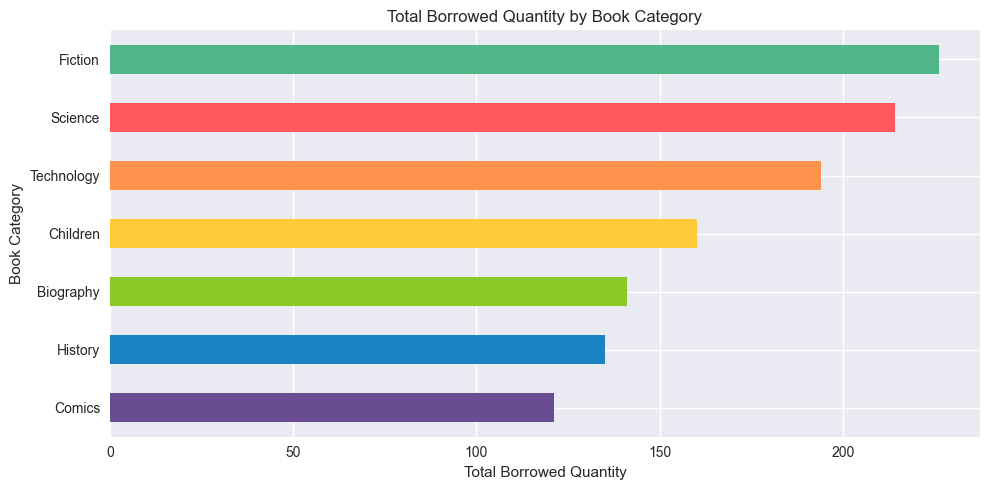

In [34]:
# Multicolor horizontal bar chart for total borrowed quantity by category
colors = ['#6a4c93', '#1982c4', '#8ac926', '#ffca3a', '#ff924c', '#ff595e', '#52b788']

plt.figure(figsize=(10, 5))
quantity_by_category.sort_values().plot(kind='barh', color=colors)
plt.title('Total Borrowed Quantity by Book Category')
plt.xlabel('Total Borrowed Quantity')
plt.ylabel('Book Category')
plt.tight_layout()
plt.show()


## Visualize Monthly Borrowing Trend


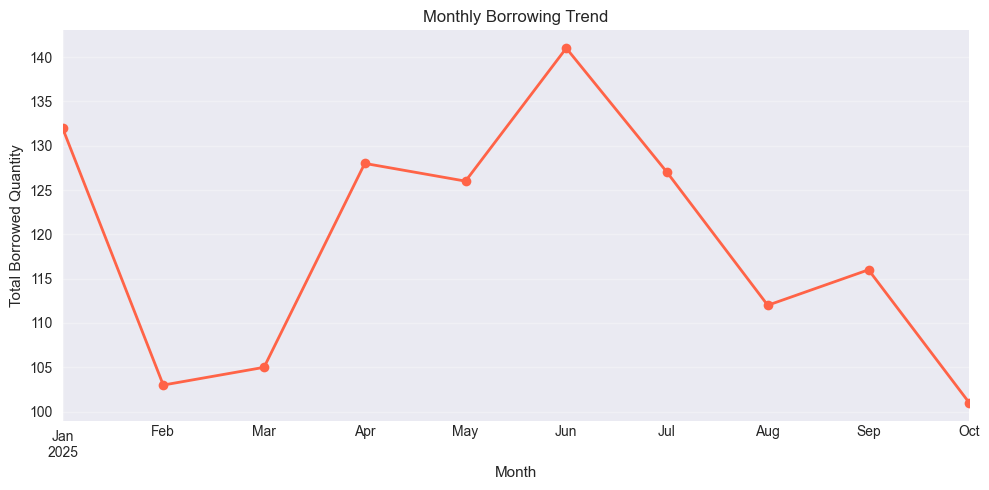

In [35]:
# Line chart for monthly borrowing trend
plt.figure(figsize=(10, 5))
monthly_borrowing.plot(marker='o', linewidth=2, color='tomato')
plt.title('Monthly Borrowing Trend')
plt.xlabel('Month')
plt.ylabel('Total Borrowed Quantity')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Visualize Borrowing by Borrower Type


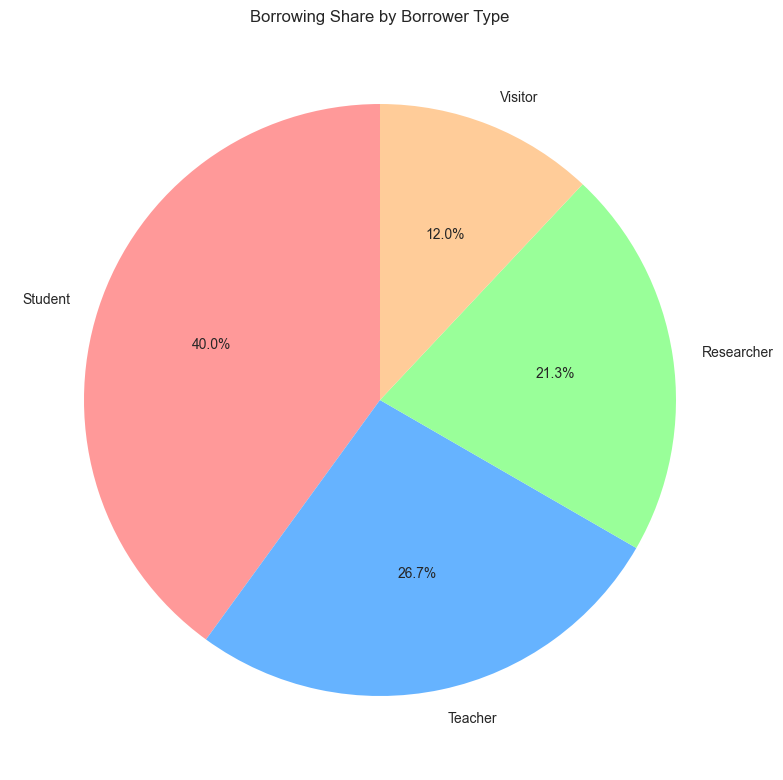

In [36]:
# Pie chart for borrower type share
borrower_counts = borrowing_data['Borrower Type'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(borrower_counts, labels=borrower_counts.index, autopct='%1.1f%%', startangle=90,
        colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
plt.title('Borrowing Share by Borrower Type')
plt.tight_layout()
plt.show()


## Visualize Return Days Distribution


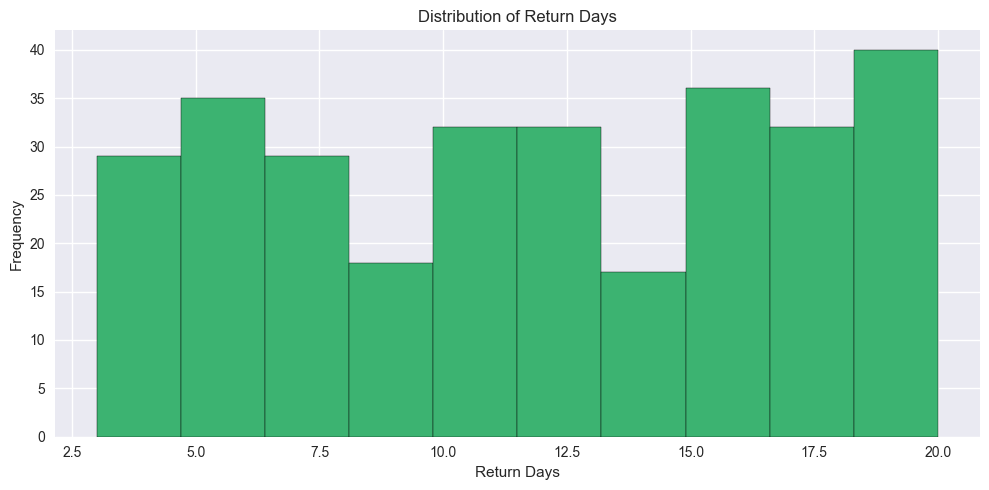

In [37]:
# Histogram of return days
plt.figure(figsize=(10, 5))
plt.hist(borrowing_data['Return Days'], bins=10, color='mediumseagreen', edgecolor='black')
plt.title('Distribution of Return Days')
plt.xlabel('Return Days')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


## Histogram of Borrowed Count

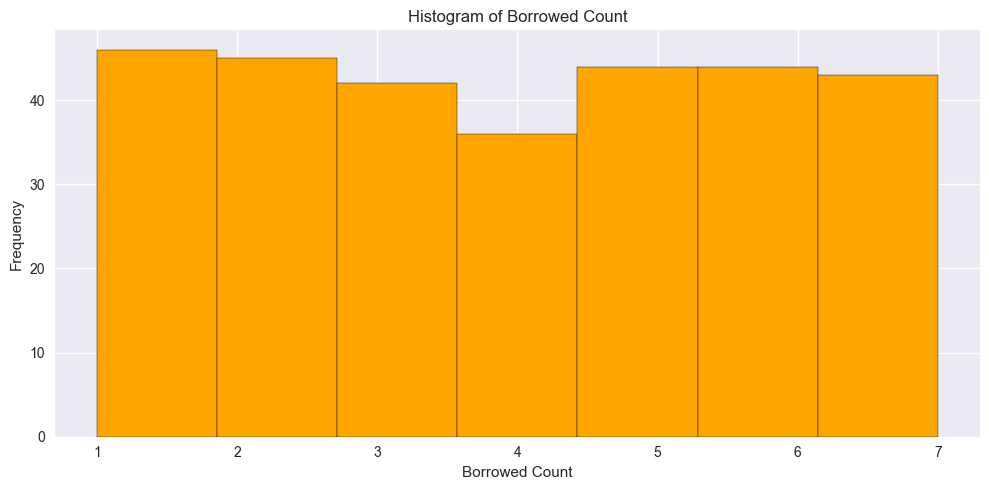

In [38]:
# Histogram of borrowed count
plt.figure(figsize=(10, 5))
plt.hist(borrowing_data['Borrowed Quantity'], bins=7, color='orange', edgecolor='black')
plt.title('Histogram of Borrowed Count')
plt.xlabel('Borrowed Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


## Histogram of Available Copies

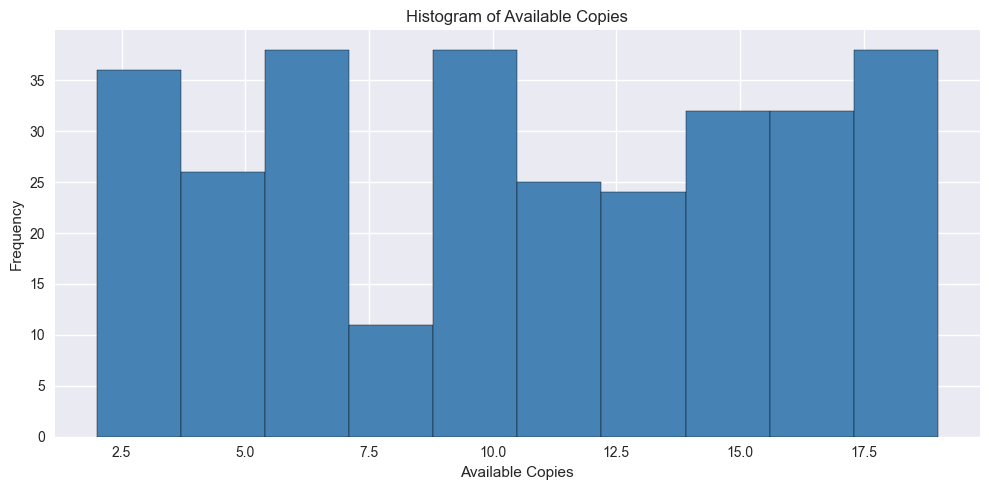

In [39]:
# First create available copies column
borrowing_data['Available Copies'] = np.random.randint(2, 20, size=len(borrowing_data))

# Histogram of available copies
plt.figure(figsize=(10, 5))
plt.hist(borrowing_data['Available Copies'], bins=10, color='steelblue', edgecolor='black')
plt.title('Histogram of Available Copies')
plt.xlabel('Available Copies')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


## Final Dataset

In [40]:
# Display final dataset
print('Final dataset shape:', borrowing_data.shape)
borrowing_data.head(10)


Final dataset shape: (300, 7)


,Borrow Date,Book Title,Category,Borrower Type,Borrowed Quantity,Return Days,Available Copies
0,2025-01-01,Hero Squad,Children,Student,3,10,4
1,2025-01-02,Python Essentials,Biography,Student,4,13,18
2,2025-01-03,Creative Coding,Biography,Student,4,6,13
3,2025-01-04,Data Thinking,History,Student,4,19,16
4,2025-01-05,Magic Forest,Biography,Teacher,4,9,17
5,2025-01-06,Hero Squad,Biography,Student,5,10,6
6,2025-01-07,Ancient Kingdoms,Comics,Student,5,5,7
7,2025-01-08,World Civilizations,Children,Student,7,4,6
8,2025-01-09,Hero Squad,Children,Teacher,2,17,4
9,2025-01-10,Creative Coding,Technology,Student,1,7,2


## Project Conclusion





### In this project, I created a **Librery Book Borrowing Analyzer** using **Python in Jupyter Notebook with Codex**.

#### First, we imported important Python libraries such as **Pandas**, **NumPy**, and **Matplotlib**. These libraries helped us create, analyze, and visualize the borrowing data.

#### Next, we generated a librery borrowing dataset containing useful columns such as:
- Borrow Date
- Book Title
- Category
- Borrower Type
- Borrowed Quantity
- Return Days
- Available Copies

#### After creating the dataset, we explored it by checking:
- the dataset shape
- column names
- data types
- summary statistics

#### Then, we analyzed the data in different ways. We counted how many times each book category appeared, compared total borrowed quantities by category, and identified the most popular category based on borrowing quantity.

#### We also analyzed borrower types to understand which group borrowed the most books. After that, we created a monthly borrowing trend to see how borrowing changed over time.

#### To make the analysis more clear and attractive, we created different charts such as:
- bar chart of borrow record count by category
- horizontal bar chart of total borrowed quantity by category
- line chart of monthly borrowing trend
- histogram of borrowed count
- histogram of available copies

#### Finally, we displayed the final dataset and wrote a conclusion based on the results. This project will make us understand how Python, Pandas, and Matplotlib can be used in Jupyter Notebook to perform data analysis and create meaningful visualizations with the help of Codex.
